In [1]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from src.config import MPL_STYLE_DIR
from src.data import DatasetLoader
from src.db import PBWarehouse
from src.config import PLOTS_DIR

plt.style.use(MPL_STYLE_DIR / "iragca_cmr10.mplstyle")

pb = PBWarehouse()
dl = DatasetLoader(pb)
df = dl.load_dataset()
df

2025-10-25 07:51:08.779 | INFO     | src.config:<module>:28 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-10-25 07:51:08.780 | INFO     | src.config:<module>:67 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-10-25 07:51:08.780 | INFO     | src.config:<module>:68 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data


✅ Loading cached dataset - Done.
✅ Loading dataset - Done.


bookmark_count,favorite_count,favourites_count,follower_count,following_count,friends,is_blue_verified,is_hateful,listed_count,number_of_tweets,quote_count,reply_count,retweet_count,source,tweet_id,user_id,views
i64,i64,i64,i64,i64,i64,bool,i64,i64,i64,i64,i64,i64,str,i64,i64,i64
0,0,941,39,6,6,false,1,0,422,0,0,0,"""""",1269916756719685632,1264846057906806786,0
23,4860,13269,95956,1596,1595,true,1,245,21715,28,334,156,"""""",1277976913743503365,23719684,0
0,2,1494,1394,427,427,false,1,30,1173,0,0,0,"""Hootsuite Inc.""",1285714950896443395,1081973336010309632,0
0,4,2675,49,165,165,false,1,3,1866,0,1,0,"""""",1284209535561818112,190751291,0
0,2,6,214664,258,258,false,1,0,310173,1,7,1,"""Twitter Media Studio - LiveCut""",1279563405536325632,121639467,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,1,2447,468,979,0,true,1,3,4284,0,1,1,"""Twitter Web App""",1269054693323530241,426170736,0
14,3034,532,30305,234,233,false,1,217,2069,86,40,1378,"""Twitter for Android""",1274010135606620161,2904953395,0
0,0,3071,54046,52576,0,true,1,382,28706,0,0,1,"""Twitter Web App""",1284986922490720257,14870085,0


In [20]:
grouped_df = df.group_by("is_hateful").agg(pl.col(["favorite_count", "reply_count", "retweet_count", "quote_count", "bookmark_count"]).mean())
grouped_df

is_hateful,favorite_count,reply_count,retweet_count,quote_count,bookmark_count
i64,f64,f64,f64,f64,f64
1,198.98228,8.698394,74.7839,6.659804,2.546508
0,75.037037,9.722222,19.314815,4.092593,1.055556
2,88.311346,5.594987,22.915567,2.828496,1.038259


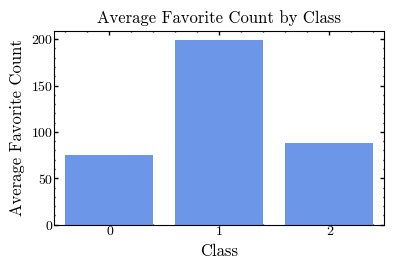

In [30]:
sns.barplot(data=grouped_df.to_pandas(), x="is_hateful", y="favorite_count")
plt.xlabel("Class")
plt.ylabel("Average Favorite Count")
plt.title("Average Favorite Count by Class")
plt.savefig(PLOTS_DIR / "avg_favorite_count_by_class.png", dpi=300, format="png", bbox_inches="tight", transparent=True)

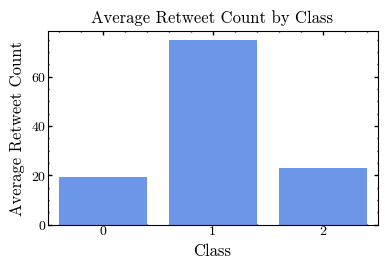

In [41]:
sns.barplot(data=grouped_df.to_pandas(), x="is_hateful", y="retweet_count")
plt.xlabel("Class")
plt.ylabel("Average Retweet Count")
plt.title("Average Retweet Count by Class")
plt.savefig(PLOTS_DIR / "avg_retweet_count_by_class.png", dpi=300, format="png", bbox_inches="tight", transparent=True)

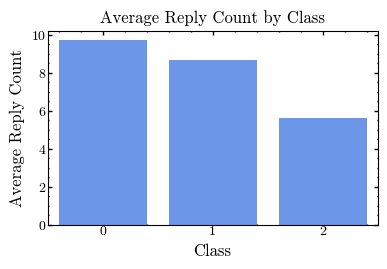

In [28]:
sns.barplot(data=grouped_df.to_pandas(), x="is_hateful", y="reply_count")
plt.xlabel("Class")
plt.ylabel("Average Reply Count")
plt.title("Average Reply Count by Class")
plt.savefig(PLOTS_DIR / "avg_reply_count_by_class.png", dpi=300, format="png", bbox_inches="tight", transparent=True)

In [38]:
df.pivot(index="user_id", on="is_hateful", values="favorite_count", aggregate_function="len").fill_null(0)["1"].mean()


1.4043133072638938

In [39]:
df.pivot(index="user_id", on="is_hateful", values="favorite_count", aggregate_function="len").fill_null(0)["0"].mean()


0.002132954141485958

In [40]:
df.pivot(index="user_id", on="is_hateful", values="favorite_count", aggregate_function="len").fill_null(0)["2"].mean()


0.02994035628233993

In [2]:
df["views"].unique()

views
i64
0


Views cant be used, garbage data

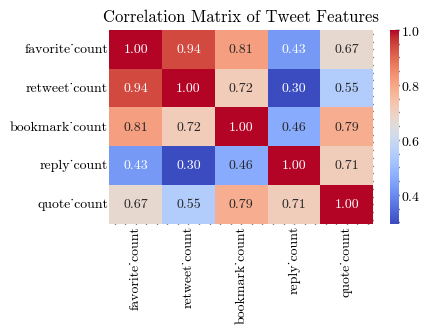

<Figure size 400x250 with 0 Axes>

In [34]:
sns.heatmap(
    df.select(
        [
            "favorite_count",
            "retweet_count",
            "bookmark_count",
            "reply_count",
            "quote_count",
            # "is_hateful",
        ]
    )
    .to_pandas()
    .corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Correlation Matrix of Tweet Features")
plt.savefig(PLOTS_DIR / "tweet_features_correlation_matrix.png", dpi=300,
            transparent=True, bbox_inches="tight", format="png")
plt.show()
plt.clf()


In [56]:
from src.data import Preprocessor


def process(text: str) -> str:
    text = Preprocessor.remove_anchor_tags(text)
    text = Preprocessor.categorize_source_str(text)

    return text


df = df.with_columns([pl.col("source").map_elements(process, return_dtype=pl.Utf8)])
df

bookmark_count,favorite_count,favourites_count,follower_count,following_count,friends,is_blue_verified,is_hateful,listed_count,number_of_tweets,quote_count,reply_count,retweet_count,source,tweet_id,user_id,views
i64,i64,i64,i64,i64,i64,bool,i64,i64,i64,i64,i64,i64,str,i64,i64,i64
0,0,941,39,6,6,false,1,0,422,0,0,0,"""unknown""",1269916756719685632,1264846057906806786,0
23,4860,13269,95956,1596,1595,true,1,245,21715,28,334,156,"""unknown""",1277976913743503365,23719684,0
0,2,1494,1394,427,427,false,1,30,1173,0,0,0,"""hootsuite inc.""",1285714950896443395,1081973336010309632,0
0,4,2675,49,165,165,false,1,3,1866,0,1,0,"""unknown""",1284209535561818112,190751291,0
0,2,6,214664,258,258,false,1,0,310173,1,7,1,"""twitter media studio - livecut""",1279563405536325632,121639467,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,1,2447,468,979,0,true,1,3,4284,0,1,1,"""twitter web app""",1269054693323530241,426170736,0
14,3034,532,30305,234,233,false,1,217,2069,86,40,1378,"""twitter for android""",1274010135606620161,2904953395,0
0,0,3071,54046,52576,0,true,1,382,28706,0,0,1,"""twitter web app""",1284986922490720257,14870085,0


In [ ]:
df["source"].value_counts(sort=True).head(10)

source,count
str,u32
"""unknown""",15853
"""twitter for iphone""",8433
"""twitter web app""",4439
"""twitter for android""",3017
"""instagram""",1144
…,…
"""revive social app""",1
"""socialist alternative website""",1
"""godaddy social app""",1


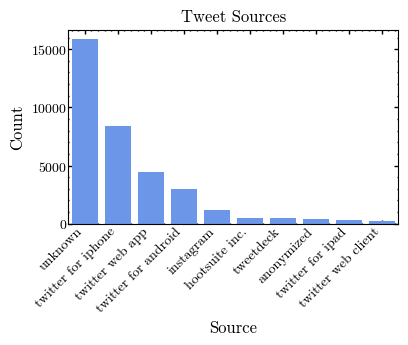

<Figure size 400x250 with 0 Axes>

In [62]:
sns.barplot(data=df["source"].value_counts(sort=True).head(10), x="source", y="count")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Source")
plt.ylabel("Count")
plt.title("Tweet Sources")
plt.savefig(PLOTS_DIR / "tweet_source_distribution.png", dpi=300,
            transparent=True, bbox_inches="tight", format="png")
plt.show()
plt.clf()

it seems like quote, reply, and favorite counts are the only suitable ones as features for minimized interdependencies.

In [4]:
from tqdm import tqdm

users = df.select(["user_id"])

user_list = []
for user in tqdm(users["user_id"].unique(), desc="Fetching users", unit="user"):
    try:
        user_list.append(pb.get_user_by_id(str(user)))
    except Exception as e:
        print(f"Error fetching user {user}: {e}")

Fetching users:  92%|█████████▏| 23346/25317 [00:30<00:02, 786.94user/s]

Error fetching user 1212852890361925632: Message: The requested resource wasn't found.
URL: N/A
Status: 404
Data: N/A
Is Abort: False
Original Error: N/A


Fetching users: 100%|██████████| 25317/25317 [00:32<00:00, 770.49user/s]


In [5]:
user_list[0].is_blue_verified

False

In [6]:
all_users = pl.DataFrame(schema={
    "favourites_count": pl.Int64,
    "follower_count": pl.Int64,
    "following_count": pl.Int64,
    "number_of_tweets": pl.Int64,
    "listed_count": pl.Int64,
    "is_blue_verified": pl.Boolean,
    "friends": pl.Int64,
})

for user in tqdm(user_list, desc="Processing users", unit="user"):
    all_users = pl.concat(
        [
            all_users,
            pl.DataFrame(
                {
                    "favourites_count": [user.favourites_count],
                    "follower_count": [user.follower_count],
                    "following_count": [user.following_count],
                    "number_of_tweets": [user.number_of_tweets],
                    "listed_count": [user.listed_count],
                    "is_blue_verified": [user.is_blue_verified],
                    "friends": [user.friends],
                }
            ),
        ],
        how="vertical",
    )

all_users

Processing users: 100%|██████████| 25316/25316 [02:56<00:00, 143.17user/s]


favourites_count,follower_count,following_count,number_of_tweets,listed_count,is_blue_verified,friends
i64,i64,i64,i64,i64,bool,i64
329138,201791,87609,101669,864,false,87531
2489,8375,5518,41229,451,false,5516
52110,721,577,17374,57,false,577
1424,37884,784,10164,1908,false,783
2452,469620,1027,42089,12654,true,1028
…,…,…,…,…,…,…
6988,2438,404,4377,29,false,404
34,0,24,90,0,false,24
32048,5,56,351,0,false,56


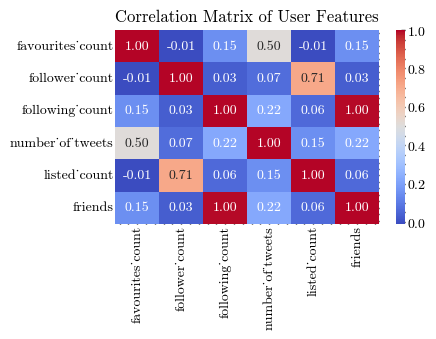

In [33]:
sns.heatmap(
    all_users.drop("is_blue_verified").to_pandas().corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Correlation Matrix of User Features")
plt.savefig(PLOTS_DIR / "user_features_correlation_matrix.png", dpi=300,
            transparent=True, bbox_inches="tight", format="png")
plt.show()

Feature choices:

- favourites_count
- follower_count or listed_count (whichever has the higher samples)
- following_count or friends (whichever has the higher samples)

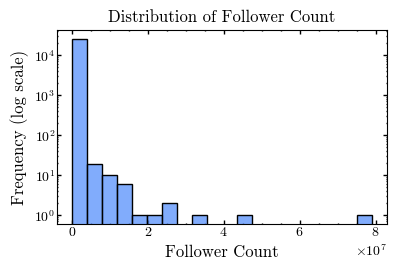

In [8]:
sns.histplot(all_users["follower_count"].to_pandas(), bins=20)
plt.yscale("log")
plt.xlabel("Follower Count")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Follower Count")
plt.savefig(PLOTS_DIR / "follower_count_distribution.png", dpi=300,
            transparent=True, bbox_inches="tight", format="png")

In [17]:
def plot_user(column: str, title: str, filename: str):
    sns.histplot(all_users[column].to_pandas(), bins=20)
    plt.yscale("log")
    plt.xlabel(f"{title}")
    plt.ylabel("Frequency (log scale)")
    plt.title(f"Distribution of {title}")
    plt.savefig(PLOTS_DIR / filename, dpi=300,
                transparent=True, bbox_inches="tight", format="png")
    plt.show()
    plt.clf()

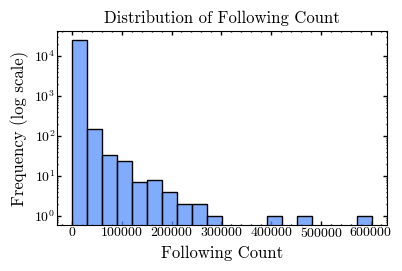

<Figure size 400x250 with 0 Axes>

In [18]:
plot_user("following_count", "Following Count", "following_count_distribution.png")

In [10]:
all_users["follower_count"].describe()

statistic,value
str,f64
"""count""",25316.0
"""null_count""",0.0
"""mean""",42085.31016
"""std""",755528.995114
"""min""",0.0
"""25%""",260.0
"""50%""",964.0
"""75%""",3646.0
"""max""",7.898758e7


In [11]:
all_users["following_count"].describe()

statistic,value
str,f64
"""count""",25316.0
"""null_count""",0.0
"""mean""",2466.464291
"""std""",9717.105023
"""min""",0.0
"""25%""",334.0
"""50%""",848.0
"""75%""",2043.0
"""max""",601576.0


In [12]:
all_users["listed_count"].describe()

statistic,value
str,f64
"""count""",25316.0
"""null_count""",0.0
"""mean""",157.842313
"""std""",1625.259343
"""min""",0.0
"""25%""",1.0
"""50%""",6.0
"""75%""",36.0
"""max""",133969.0


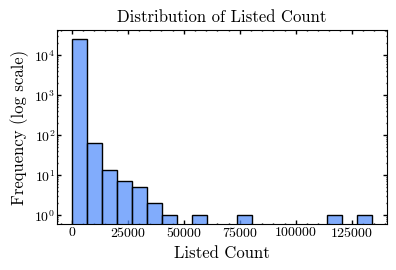

<Figure size 400x250 with 0 Axes>

In [19]:
plot_user("listed_count", "Listed Count", "listed_count_distribution.png")

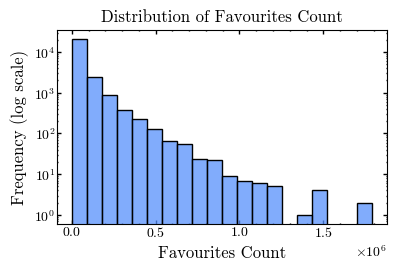

<Figure size 400x250 with 0 Axes>

In [22]:
plot_user("favourites_count", "Favourites Count", "favourites_count_distribution.png")

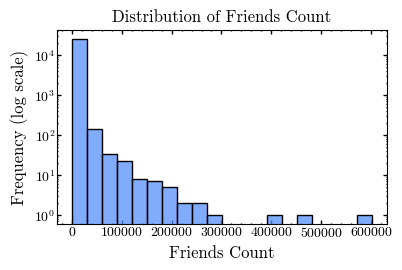

<Figure size 400x250 with 0 Axes>

In [23]:
plot_user("friends", "Friends Count", "friends_count_distribution.png")

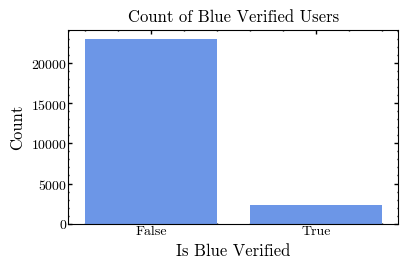

In [21]:
sns.countplot(
    x="is_blue_verified",
    data=all_users.to_pandas(),
)
plt.xlabel("Is Blue Verified")
plt.ylabel("Count")
plt.title("Count of Blue Verified Users")
plt.savefig(PLOTS_DIR / "is_blue_verified_count.png", dpi=300,
            transparent=True, bbox_inches="tight", format="png")

In [24]:
def plot_tweet(column: str, title: str, filename: str):
    sns.histplot(df[column].to_pandas(), bins=20)
    plt.yscale("log")
    plt.xlabel(f"{title}")
    plt.ylabel("Frequency (log scale)")
    plt.title(f"Distribution of {title}")
    plt.savefig(PLOTS_DIR / filename, dpi=300,
                transparent=True, bbox_inches="tight", format="png")
    plt.show()
    plt.clf()

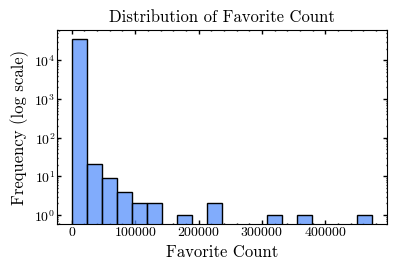

<Figure size 400x250 with 0 Axes>

In [25]:
plot_tweet("favorite_count", "Favorite Count", "favorite_count_distribution.png")

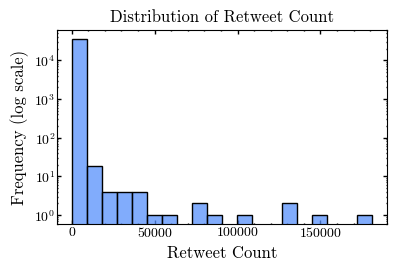

<Figure size 400x250 with 0 Axes>

In [27]:
plot_tweet("retweet_count", "Retweet Count", "retweet_count_distribution.png")

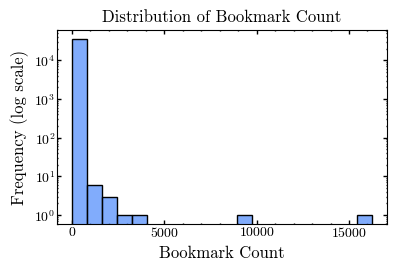

<Figure size 400x250 with 0 Axes>

In [28]:
plot_tweet("bookmark_count", "Bookmark Count", "bookmark_count_distribution.png")

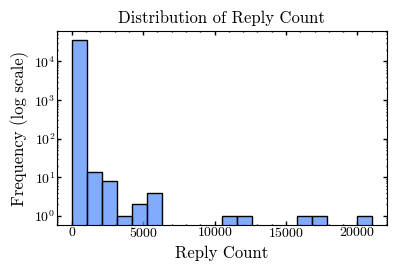

<Figure size 400x250 with 0 Axes>

In [29]:
plot_tweet("reply_count", "Reply Count", "reply_count_distribution.png")

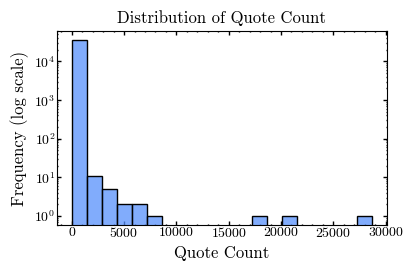

<Figure size 400x250 with 0 Axes>

In [30]:
plot_tweet("quote_count", "Quote Count", "quote_count_distribution.png")

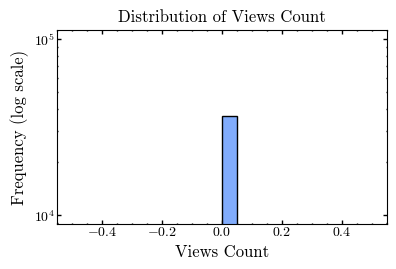

<Figure size 400x250 with 0 Axes>

In [31]:
plot_tweet("views", "Views Count", "views_count_distribution.png")

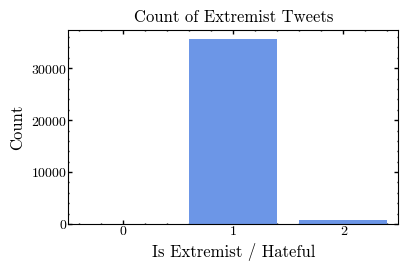

<Figure size 400x250 with 0 Axes>

In [32]:
sns.countplot(
    x="is_hateful",
    data=df.to_pandas(),
)
plt.xlabel("Is Extremist / Hateful")
plt.ylabel("Count")
plt.title("Count of Extremist Tweets")
plt.savefig(PLOTS_DIR / "is_extremist_count.png", dpi=300,
            transparent=True, bbox_inches="tight", format="png")
plt.show()
plt.clf()